# EDA — Contaminación por localidad (cont_loc_mean.csv) e INEGI Censo 2020 (inegi_loc.csv)


## 0. Datos de entrada

Este notebook necesita `cont_loc_mean.csv` e `inegi_loc.csv`.

- **Opción A (default):** ejecuta la celda siguiente y súbelos con el selector de archivos.
- **Opción B:** si ya están en tu Google Drive, descomenta el bloque de `drive.mount` y apunta `DATA_DIR` a la carpeta que los contiene.

In [ ]:
from pathlib import Path

DATA_DIR = Path(".")
ARCHIVOS = ["cont_loc_mean.csv", "inegi_loc.csv"]

# --- Opción B: Google Drive ---
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = Path("/content/drive/MyDrive/<tu_carpeta>")

faltantes = [a for a in ARCHIVOS if not (DATA_DIR / a).exists()]

if faltantes:
    try:
        from google.colab import files
        print("Sube los archivos:", ", ".join(faltantes))
        files.upload()
    except ImportError:
        pass
    faltantes = [a for a in ARCHIVOS if not (DATA_DIR / a).exists()]

if faltantes:
    raise FileNotFoundError(f"Faltan los archivos: {faltantes}. Súbelos o ajusta DATA_DIR.")

print("Archivos listos en:", DATA_DIR.resolve())

In [47]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

CLAVE = ["ENTIDAD", "MUN", "LOC"]
DTYPES = {"ENTIDAD": str, "MUN": str, "LOC": str}

cont = pd.read_csv(DATA_DIR / "cont_loc_mean.csv", dtype=DTYPES)
inegi = pd.read_csv(DATA_DIR / "inegi_loc.csv", dtype=DTYPES, low_memory=False)

print("cont_loc_mean:", cont.shape)
print("inegi_loc:    ", inegi.shape)

cont_loc_mean: (494, 11)
inegi_loc:     (5085, 232)


## 1. Estructura de las fuentes

In [48]:
POL = ["co_mean", "no_mean", "no2_mean", "nox_mean", "o3_mean", "pm10_mean", "pm25_mean", "so2_mean"]

display(cont.head())
print(cont.dtypes.to_string())

,ENTIDAD,MUN,LOC,co_mean,no_mean,no2_mean,nox_mean,o3_mean,pm10_mean,pm25_mean,so2_mean
0,09,002,0001,4.1384,14.7886,29.6086,55.5230,33.6003,48.6623,25.9689,6.9187
1,09,003,0001,0.1054,10.2789,28.0446,46.1454,32.6267,43.8851,22.4923,8.4591
2,09,004,0001,0.1990,28.0697,24.0281,47.6787,36.5992,36.9912,20.2182,8.4912
3,09,004,0010,0.1304,34.0935,22.9196,46.7826,36.9091,35.6014,18.9092,8.8559
4,09,004,0020,0.1481,33.4792,23.1875,49.4673,36.7820,35.7967,19.1848,8.7384


ENTIDAD       object
MUN           object
LOC           object
co_mean      float64
no_mean      float64
no2_mean     float64
nox_mean     float64
o3_mean      float64
pm10_mean    float64
pm25_mean    float64
so2_mean     float64


In [49]:
display(inegi.iloc[:, :12].head())
print("Columnas INEGI:", inegi.shape[1])
print("Identificadores :", [c for c in inegi.columns[:9]])
print("Bloques temáticos (muestra):", list(inegi.columns[9:25]))

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS
0,09,Ciudad de México,002,Azcapotzalco,0001,Azcapotzalco,"99°11'03.698"" W","19°29'02.770"" N",2244,432205,227255,204950
1,09,Ciudad de México,003,Coyoacán,0001,Coyoacán,"99°09'43.724"" W","19°21'00.770"" N",2247,614447,325337,289110
2,09,Ciudad de México,004,Cuajimalpa de Morelos,0001,Cuajimalpa de Morelos,"99°17'59.252"" W","19°21'26.461"" N",2780,186693,97615,89078
3,09,Ciudad de México,004,Cuajimalpa de Morelos,0010,Cruz Blanca,"99°19'26.437"" W","19°19'04.026"" N",2982,728,362,366
4,09,Ciudad de México,004,Cuajimalpa de Morelos,0020,San Lorenzo Acopilco,"99°19'32.454"" W","19°19'51.617"" N",2936,26042,13416,12626


Columnas INEGI: 232
Identificadores : ['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'LONGITUD', 'LATITUD', 'ALTITUD']
Bloques temáticos (muestra): ['POBTOT', 'POBFEM', 'POBMAS', 'P_0A2', 'P_0A2_F', 'P_0A2_M', 'P_3YMAS', 'P_3YMAS_F', 'P_3YMAS_M', 'P_5YMAS', 'P_5YMAS_F', 'P_5YMAS_M', 'P_12YMAS', 'P_12YMAS_F', 'P_12YMAS_M', 'P_15YMAS']


## 2. Calidad de datos

In [50]:
def resumen_calidad(df, nombre):
    return pd.Series({
        "filas": len(df),
        "columnas": df.shape[1],
        "celdas_nulas": int(df.isna().sum().sum()),
        "columnas_con_nulos": int((df.isna().sum() > 0).sum()),
        "filas_duplicadas": int(df.duplicated().sum()),
        "claves_duplicadas": int(df.duplicated(subset=CLAVE).sum()),
    }, name=nombre)

calidad = pd.concat([resumen_calidad(cont, "cont_loc_mean"),
                     resumen_calidad(inegi, "inegi_loc")], axis=1)
display(calidad)

,cont_loc_mean,inegi_loc
filas,494,5085
columnas,11,232
celdas_nulas,0,0
columnas_con_nulos,0,0
filas_duplicadas,0,0
claves_duplicadas,0,0


In [51]:
nulos_inegi = inegi.isna().sum()
nulos_inegi = nulos_inegi[nulos_inegi > 0].sort_values(ascending=False)
print("Columnas de INEGI con nulos:", len(nulos_inegi))
display(nulos_inegi.head(15).to_frame("nulos"))

Columnas de INEGI con nulos: 0


,nulos


In [52]:
num_inegi = inegi.select_dtypes("number")
print("Columnas numéricas INEGI:", num_inegi.shape[1])
print("Columnas con valores negativos:", int((num_inegi.min() < 0).sum()))
print("Localidades con POBTOT == 0:", int((inegi.POBTOT == 0).sum()))
print("\nLONGITUD / LATITUD vienen como texto en grados-minutos-segundos:")
display(inegi[["NOM_LOC", "LONGITUD", "LATITUD", "ALTITUD"]].head(3))

Columnas numéricas INEGI: 224
Columnas con valores negativos: 0
Localidades con POBTOT == 0: 0

LONGITUD / LATITUD vienen como texto en grados-minutos-segundos:


,NOM_LOC,LONGITUD,LATITUD,ALTITUD
0,Azcapotzalco,"99°11'03.698"" W","19°29'02.770"" N",2244
1,Coyoacán,"99°09'43.724"" W","19°21'00.770"" N",2247
2,Cuajimalpa de Morelos,"99°17'59.252"" W","19°21'26.461"" N",2780


In [53]:
def dms_a_decimal(valor):
    m = re.match(r"\s*(\d+)°(\d+)'([\d.]+)\"\s*([NSEW])", str(valor))
    if not m:
        return np.nan
    grados = float(m.group(1)) + float(m.group(2)) / 60 + float(m.group(3)) / 3600
    return -grados if m.group(4) in ("W", "S") else grados

inegi["lon"] = inegi["LONGITUD"].map(dms_a_decimal)
inegi["lat"] = inegi["LATITUD"].map(dms_a_decimal)

print("Coordenadas no parseadas:", int(inegi[["lon", "lat"]].isna().any(axis=1).sum()))
display(inegi[["lon", "lat", "ALTITUD"]].describe().round(3))

Coordenadas no parseadas: 0


,lon,lat,ALTITUD
count,5085.000,5085.000,5085.000
mean,-99.595,19.336,2301.781
std,0.476,0.382,557.698
min,-100.580,18.370,345.000
25%,-99.996,19.068,2237.000
50%,-99.632,19.319,2466.000
75%,-99.158,19.648,2651.000
max,-98.619,20.274,3498.000


## 3. Cobertura geográfica y compatibilidad de las dos fuentes

In [54]:
cobertura = pd.DataFrame({
    "cont_loc_mean": cont.ENTIDAD.value_counts(),
    "inegi_loc": inegi.ENTIDAD.value_counts(),
}).fillna(0).astype(int)
cobertura.index = cobertura.index.map({"09": "09 Ciudad de México", "15": "15 México"})
display(cobertura)

,cont_loc_mean,inegi_loc
ENTIDAD,,
09 Ciudad de México,494,494
15 México,0,4591


In [55]:
cont["cve_loc"] = cont[CLAVE].agg("".join, axis=1)
inegi["cve_loc"] = inegi[CLAVE].agg("".join, axis=1)

print("Claves de cont presentes en INEGI:", int(cont.cve_loc.isin(inegi.cve_loc).sum()), "/", len(cont))
print("Claves de INEGI presentes en cont:", int(inegi.cve_loc.isin(cont.cve_loc).sum()), "/", len(inegi))
print("Localidades de INEGI sin medición de contaminación:", int((~inegi.cve_loc.isin(cont.cve_loc)).sum()))

df = cont.merge(inegi, on=CLAVE + ["cve_loc"], how="inner")
print("\nTabla integrada:", df.shape)

Claves de cont presentes en INEGI: 494 / 494
Claves de INEGI presentes en cont: 494 / 5085
Localidades de INEGI sin medición de contaminación: 4591

Tabla integrada: (494, 243)


La llave `ENTIDAD+MUN+LOC` empata de forma perfecta y sin duplicados, pero el cruce **queda restringido a la Ciudad de México**: las 4,591 localidades del Estado de México presentes en INEGI no tienen datos de contaminación.

## 4. Variables de contaminación

In [56]:
desc = cont[POL].describe().T
desc["cv"] = desc["std"] / desc["mean"]
desc["asimetria"] = cont[POL].skew()
display(desc.round(3))

,count,mean,std,min,25%,50%,75%,max,cv,asimetria
co_mean,494.0,0.074,0.317,0.018,0.028,0.034,0.047,5.387,4.306,14.200
no_mean,494.0,28.302,5.045,7.448,26.331,29.123,31.737,40.653,0.178,-1.177
no2_mean,494.0,19.632,2.245,16.082,18.035,19.333,20.656,30.416,0.114,1.651
nox_mean,494.0,44.777,1.884,41.646,43.590,44.522,45.358,55.523,0.042,1.942
o3_mean,494.0,37.225,1.445,31.664,36.572,37.257,38.011,40.347,0.039,-0.792
pm10_mean,494.0,43.267,3.504,34.485,41.283,43.691,45.237,53.211,0.081,-0.019
pm25_mean,494.0,20.889,1.005,18.009,20.266,21.056,21.435,25.969,0.048,0.389
so2_mean,494.0,9.812,0.470,6.919,9.744,9.954,10.070,10.313,0.048,-2.674


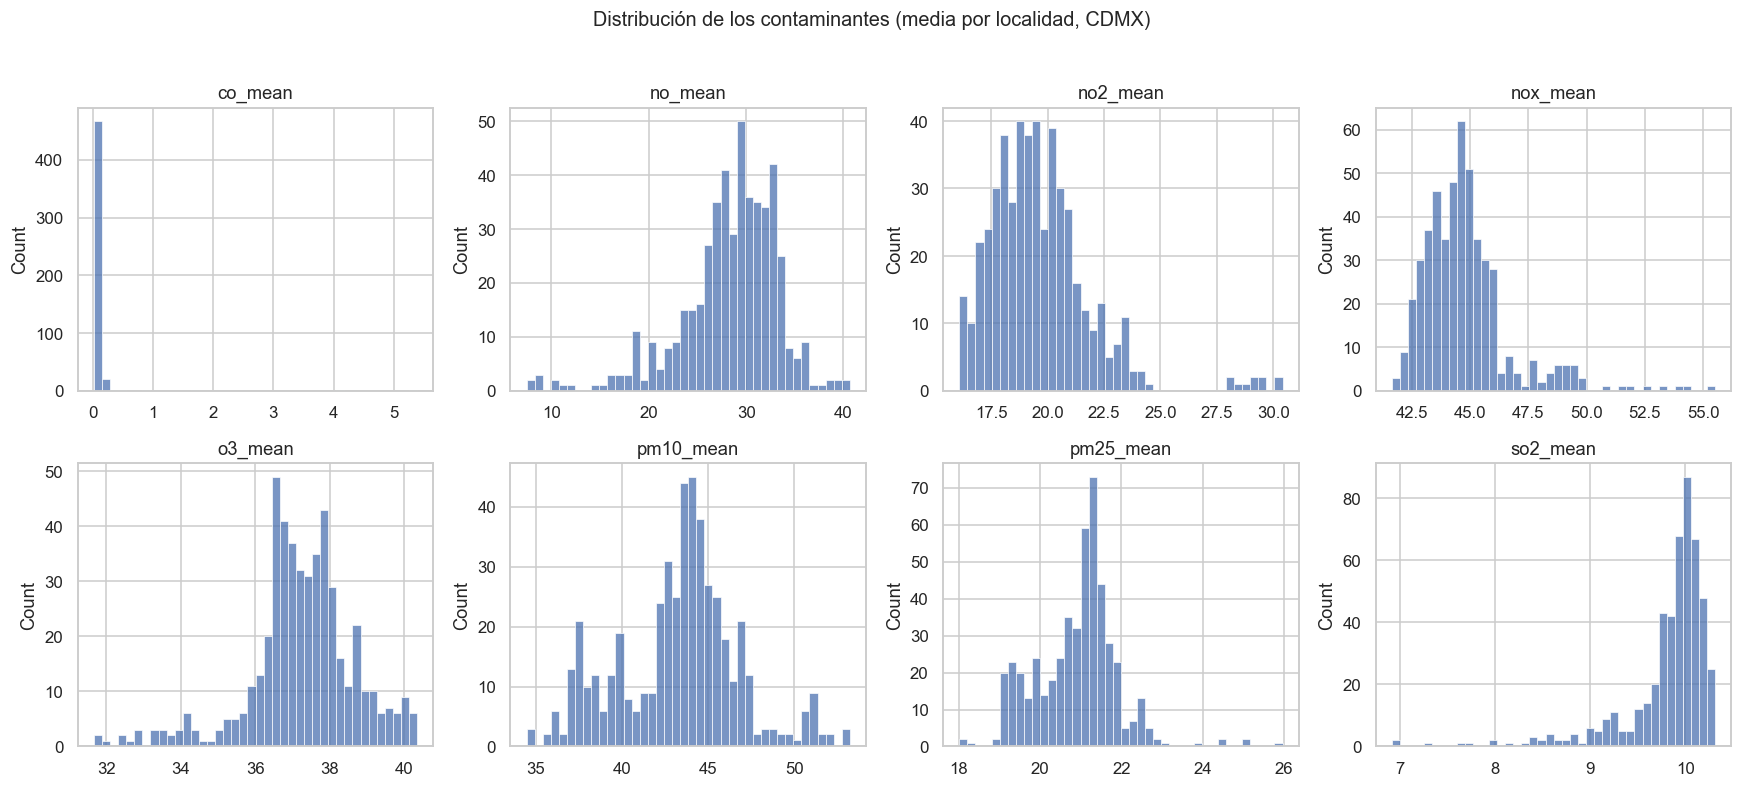

In [57]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), POL):
    sns.histplot(cont[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribución de los contaminantes (media por localidad, CDMX)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

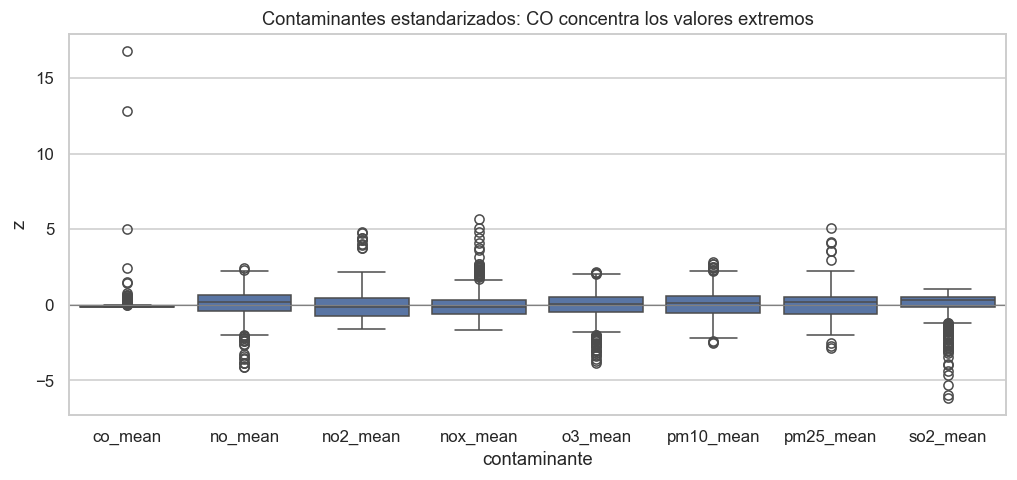

Rango intercuartílico de CO: 0.0193
Máximo de CO: 5.387 | mediana: 0.03395
Localidades con CO > 1: 3


In [58]:
z = (cont[POL] - cont[POL].mean()) / cont[POL].std()
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=z.melt(var_name="contaminante", value_name="z"), x="contaminante", y="z", ax=ax)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Contaminantes estandarizados: CO concentra los valores extremos")
plt.show()

print("Rango intercuartílico de CO:", round(cont.co_mean.quantile(.75) - cont.co_mean.quantile(.25), 4))
print("Máximo de CO:", cont.co_mean.max(), "| mediana:", cont.co_mean.median())
print("Localidades con CO > 1:", int((cont.co_mean > 1).sum()))

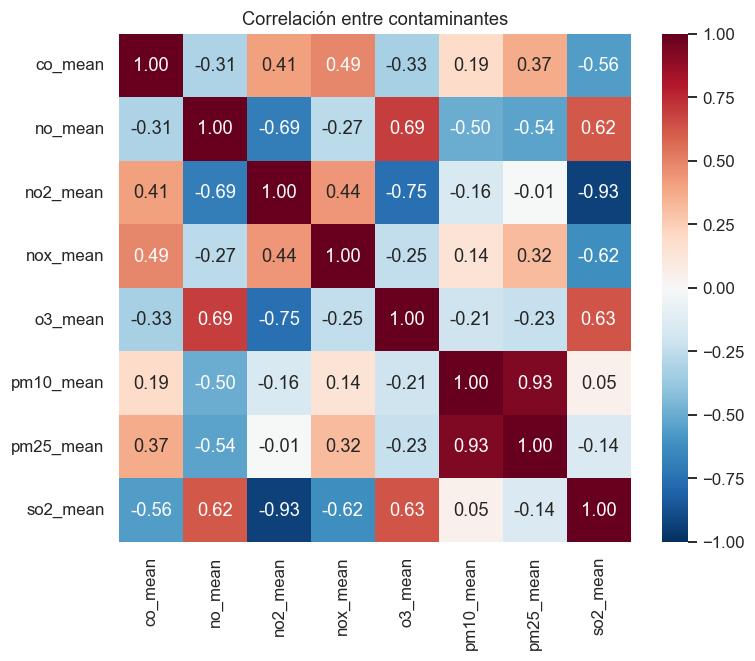

In [59]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cont[POL].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre contaminantes")
plt.show()

Dos bloques opuestos: **PM10–PM2.5 (r = 0.93)** por un lado y **O3–NO (r = 0.69)** por otro, con **NO2 y SO2 casi perfectamente inversos (r = -0.93)**. El patrón es consistente con química atmosférica: donde hay más NO2 (tráfico) el ozono se titula a la baja.

## 5. Variables INEGI: estructura poblacional

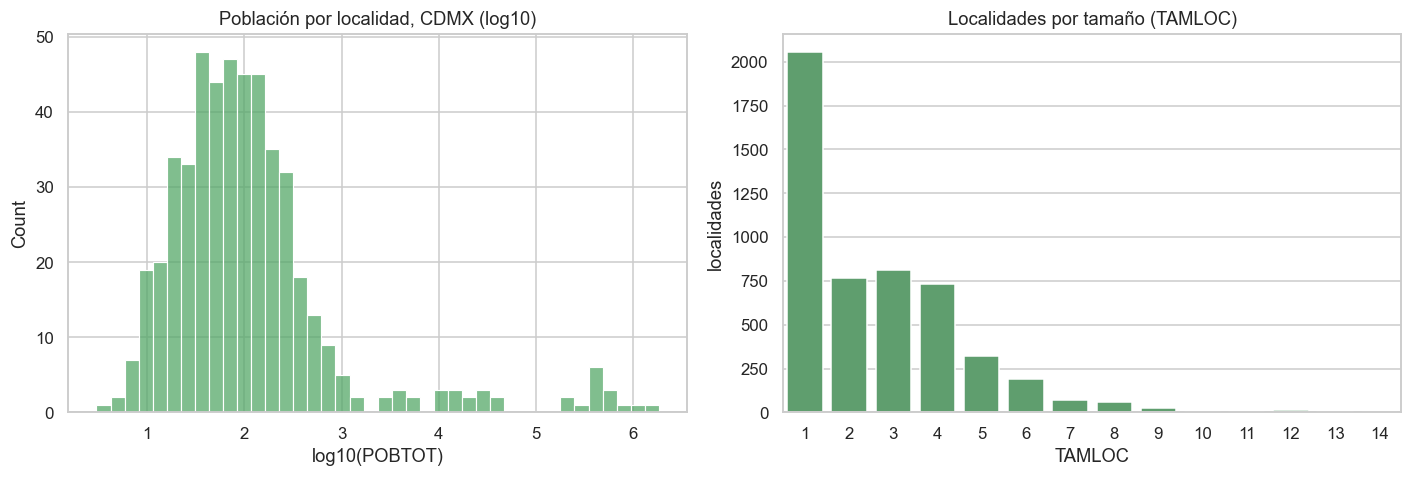

,POBTOT CDMX
count,494.0
mean,18642.2
std,123220.3
min,3.0
25%,32.0
50%,77.0
75%,207.0
max,1835486.0


In [60]:
cdmx = inegi[inegi.ENTIDAD == "09"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(np.log10(cdmx.POBTOT), bins=40, ax=axes[0], color="#55A868")
axes[0].set(title="Población por localidad, CDMX (log10)", xlabel="log10(POBTOT)")
orden = inegi.TAMLOC.value_counts().sort_index()
sns.barplot(x=orden.index, y=orden.values, ax=axes[1], color="#55A868")
axes[1].set(title="Localidades por tamaño (TAMLOC)", xlabel="TAMLOC", ylabel="localidades")
fig.tight_layout()
plt.show()

display(cdmx.POBTOT.describe().round(1).to_frame("POBTOT CDMX"))

In [61]:
resumen_alcaldia = (cdmx.groupby("NOM_MUN")
                        .agg(localidades=("POBTOT", "size"), poblacion=("POBTOT", "sum"),
                             pob_mediana=("POBTOT", "median"), escolaridad=("GRAPROES", "mean"))
                        .sort_values("poblacion", ascending=False))
display(resumen_alcaldia.round(2))

,localidades,poblacion,pob_mediana,escolaridad
NOM_MUN,,,,
Iztapalapa,1,1835486,1835486.0,10.42
Gustavo A. Madero,1,1173351,1173351.0,11.11
Álvaro Obregón,6,759133,29.5,7.30
Tlalpan,94,699605,69.0,8.75
Coyoacán,1,614447,614447.0,12.51
Cuauhtémoc,1,545884,545884.0,12.41
Venustiano Carranza,1,443704,443704.0,11.46
Xochimilco,97,442113,62.0,8.77
Benito Juárez,1,434153,434153.0,14.55


La unidad "localidad" no es homogénea: nueve alcaldías del centro-norte están registradas como **una sola localidad** de cientos de miles de habitantes, mientras que Milpa Alta, Xochimilco y Tlalpan aportan 404 localidades rurales con **mediana de 77 habitantes**. Cualquier estadístico simple por localidad estará dominado por el sur rural.

## 6. Indicadores socioeconómicos derivados

In [62]:
df["pct_sin_derechohab"] = df.PSINDER / df.POBTOT * 100
df["pct_viv_internet"] = df.VPH_INTER / df.VIVPAR_HAB * 100
df["pct_analfabetismo"] = df.P15YM_AN / df.P_15YMAS * 100
df["pct_desocupacion"] = df.PDESOCUP / df.PEA * 100
df["pct_pob_65mas"] = df.POB65_MAS / df.POBTOT * 100
df["pct_pob_0a14"] = df.POB0_14 / df.POBTOT * 100

SOCIO = ["POBTOT", "GRAPROES", "pct_sin_derechohab", "pct_viv_internet",
         "pct_analfabetismo", "pct_desocupacion", "pct_pob_65mas", "PROM_OCUP", "ALTITUD"]
display(df[SOCIO].describe().round(2))

,POBTOT,GRAPROES,pct_sin_derechohab,pct_viv_internet,pct_analfabetismo,pct_desocupacion,pct_pob_65mas,PROM_OCUP,ALTITUD
count,494.00,494.00,494.00,494.00,494.00,494.00,494.00,494.00,494.00
mean,18642.23,8.92,36.06,34.19,4.58,1.68,5.40,3.76,2583.46
std,123220.35,1.49,17.06,24.38,5.28,5.01,5.14,0.69,241.02
min,3.00,4.50,0.00,0.00,0.00,0.00,0.00,1.00,2217.00
25%,32.00,8.13,25.46,16.09,1.34,0.00,2.64,3.39,2387.25
50%,77.00,8.81,33.33,31.58,3.41,0.00,4.27,3.79,2572.00
75%,207.00,9.67,45.61,50.00,5.88,2.09,6.94,4.14,2757.00
max,1835486.00,16.09,100.00,130.77,46.67,85.71,50.00,6.17,3280.00


## 7. Gradiente espacial de la contaminación

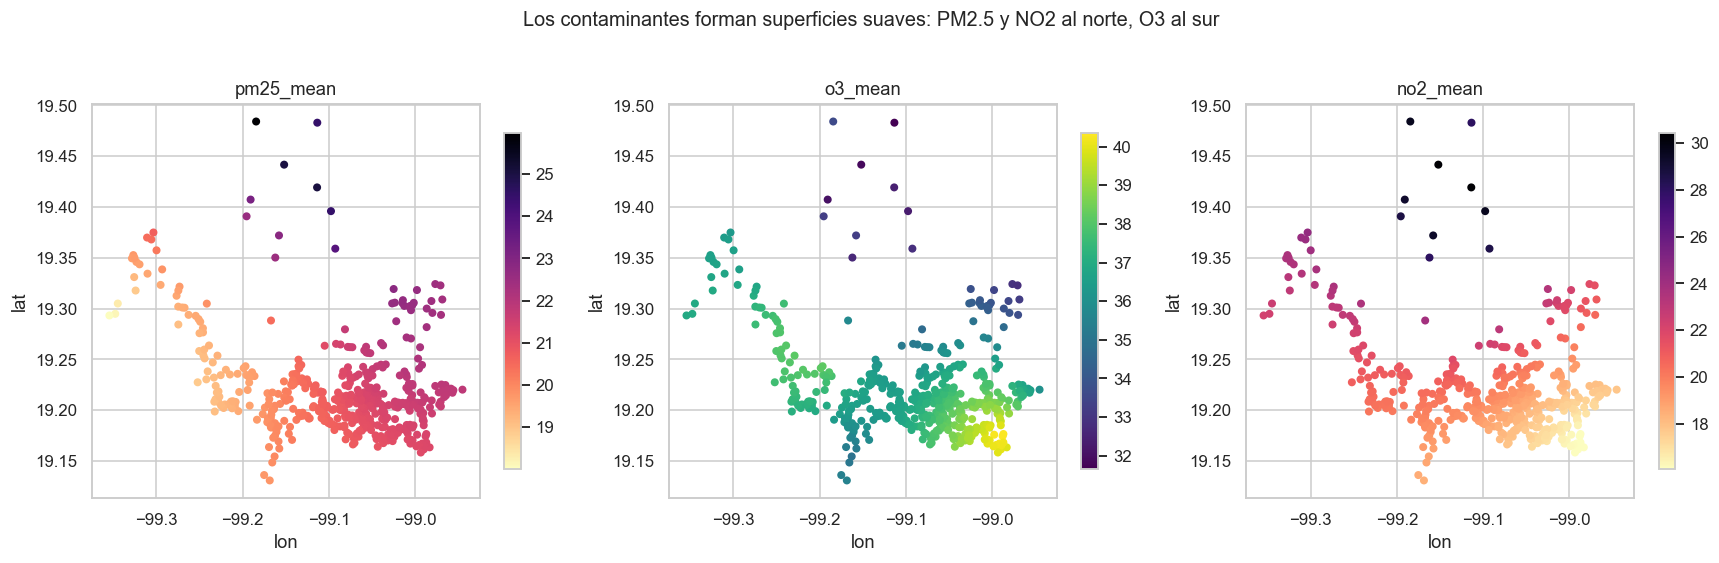

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, cmap in zip(axes, ["pm25_mean", "o3_mean", "no2_mean"], ["magma_r", "viridis", "magma_r"]):
    s = ax.scatter(df.lon, df.lat, c=df[col], cmap=cmap, s=18)
    plt.colorbar(s, ax=ax, shrink=0.85)
    ax.set(title=col, xlabel="lon", ylabel="lat")
fig.suptitle("Los contaminantes forman superficies suaves: PM2.5 y NO2 al norte, O3 al sur", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

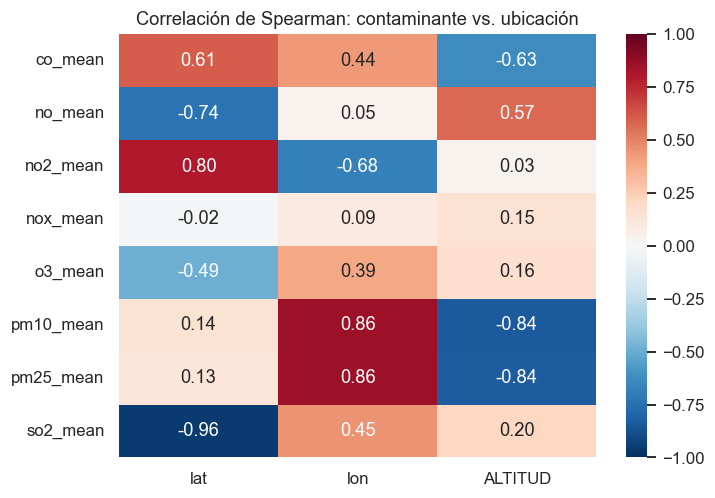

In [64]:
geo = ["lat", "lon", "ALTITUD"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[POL + geo].corr(method="spearman").loc[POL, geo],
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman: contaminante vs. ubicación")
plt.show()

La ubicación explica casi toda la variación: **SO2 vs. latitud ρ = -0.96**, **NO2 vs. latitud ρ = 0.80**, **PM2.5 vs. longitud ρ = 0.86**. Los valores se comportan como una **superficie interpolada a partir de pocas estaciones de monitoreo**, no como mediciones independientes por localidad — hay que tratarlos como covariables espaciales, no como observaciones i.i.d.

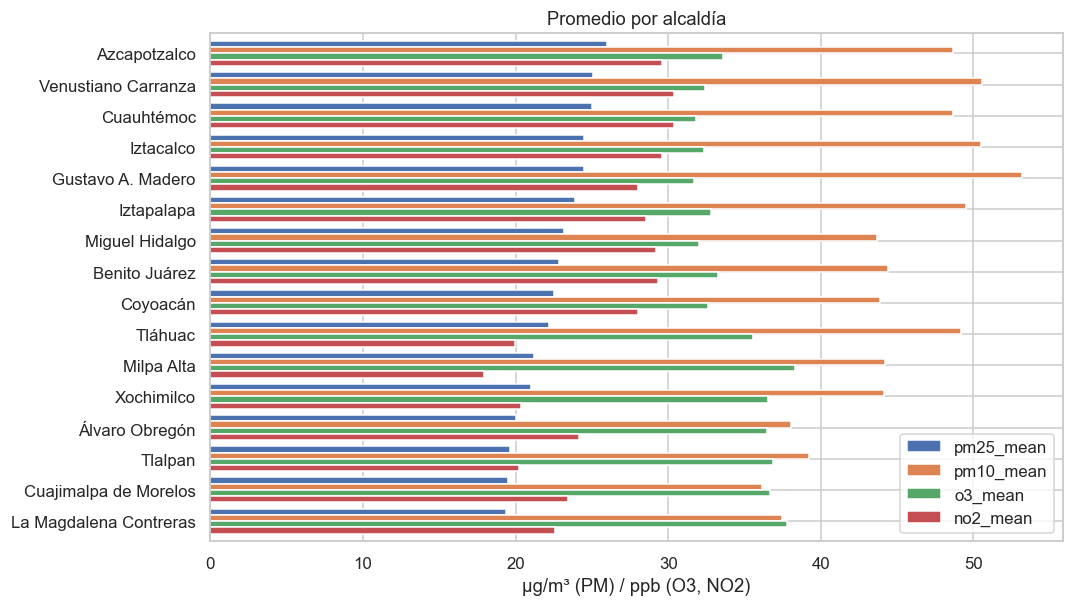

,co_mean,no_mean,no2_mean,nox_mean,o3_mean,pm10_mean,pm25_mean,so2_mean
NOM_MUN,,,,,,,,
Azcapotzalco,4.14,14.79,29.61,55.52,33.60,48.66,25.97,6.92
Venustiano Carranza,0.85,7.45,30.37,53.14,32.44,50.55,25.06,7.61
Cuauhtémoc,1.66,8.95,30.42,54.38,31.84,48.69,25.03,7.32
Iztacalco,0.55,7.67,29.60,49.56,32.34,50.47,24.49,7.95
Gustavo A. Madero,5.39,11.76,28.05,53.86,31.66,53.21,24.48,7.00
Iztapalapa,0.17,8.76,28.54,50.76,32.84,49.55,23.87,8.42
Miguel Hidalgo,0.54,10.65,29.20,51.62,32.05,43.71,23.16,7.75
Benito Juárez,0.20,8.92,29.30,51.92,33.24,44.40,22.85,8.18
Coyoacán,0.11,10.28,28.04,46.15,32.63,43.89,22.49,8.46


In [65]:
por_alcaldia = df.groupby("NOM_MUN")[POL].mean().sort_values("pm25_mean", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
por_alcaldia[["pm25_mean", "pm10_mean", "o3_mean", "no2_mean"]].plot.barh(ax=ax, width=0.8)
ax.invert_yaxis()
ax.set(title="Promedio por alcaldía", xlabel="µg/m³ (PM) / ppb (O3, NO2)", ylabel="")
ax.legend(loc="lower right")
plt.show()
display(por_alcaldia.round(2))

## 8. Contaminación vs. características sociodemográficas

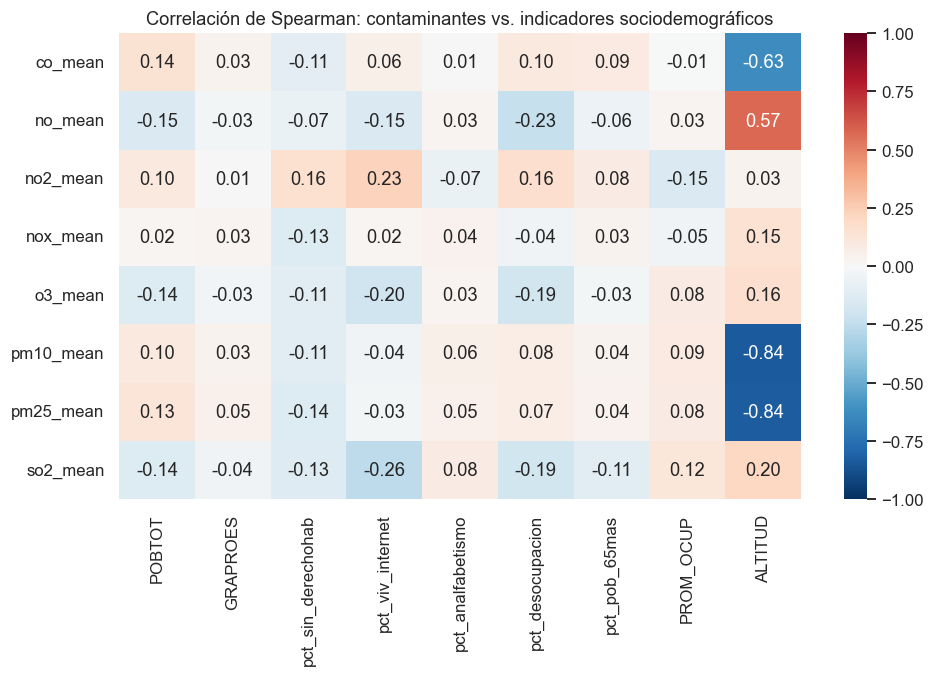

In [66]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(df[POL + SOCIO].corr(method="spearman").loc[POL, SOCIO],
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Spearman: contaminantes vs. indicadores sociodemográficos")
plt.show()

/var/folders/v6/02p113jx7f7f1z845lg5j6m00000gn/T/ipykernel_88232/2885066421.py:6: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/sayuriherreramoreno/.pyenv/versions/3.13.7/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


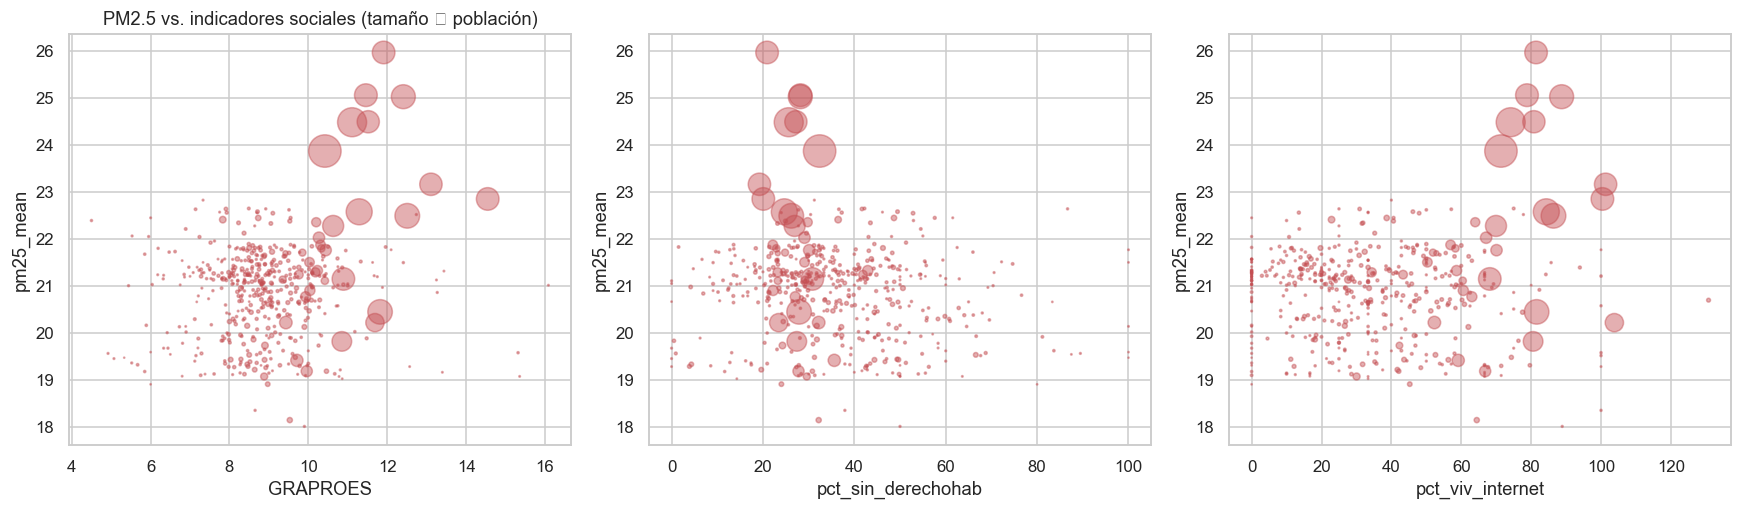

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, col in zip(axes, ["GRAPROES", "pct_sin_derechohab", "pct_viv_internet"]):
    ax.scatter(df[col], df.pm25_mean, s=np.sqrt(df.POBTOT) / 3, alpha=0.45, color="#C44E52")
    ax.set(xlabel=col, ylabel="pm25_mean")
axes[0].set_title("PM2.5 vs. indicadores sociales (tamaño ∝ población)")
fig.tight_layout()
plt.show()

In [68]:
comparacion = pd.DataFrame({
    "media_simple": df[POL].mean(),
    "media_ponderada_pob": [np.average(df[c], weights=df.POBTOT) for c in POL],
})
comparacion["dif_%"] = (comparacion.media_ponderada_pob / comparacion.media_simple - 1) * 100
display(comparacion.round(3))

,media_simple,media_ponderada_pob,dif_%
co_mean,0.074,1.161,1477.936
no_mean,28.302,12.792,-54.801
no2_mean,19.632,27.353,39.333
nox_mean,44.777,50.226,12.170
o3_mean,37.225,33.407,-10.256
pm10_mean,43.267,47.073,8.797
pm25_mean,20.889,23.213,11.125
so2_mean,9.812,8.181,-16.623


,localidades,pm25,o3,no2,escolaridad
grupo_pob,,,,,
<100,278,20.78,37.40,19.35,8.73
100-1k,176,20.88,37.24,19.52,8.87
1k-10k,13,20.95,36.97,19.27,9.27
10k-100k,12,21.05,37.40,18.97,10.06
>100k,15,22.93,33.78,27.08,11.74


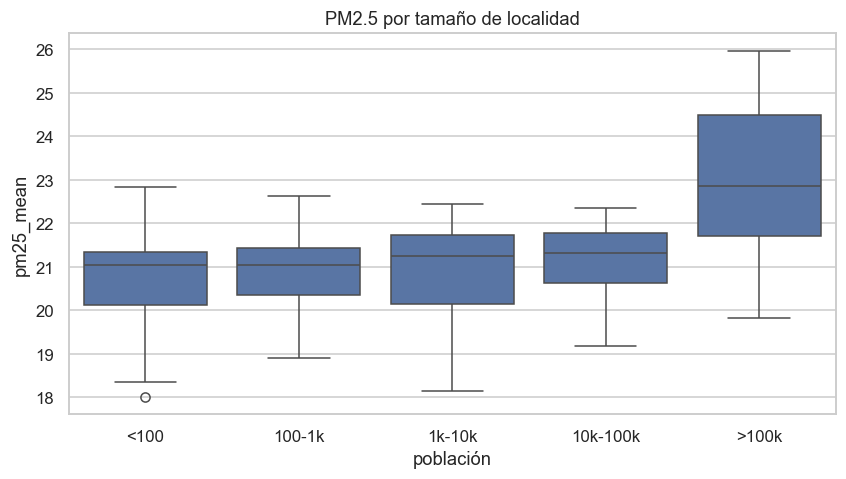

In [69]:
df["grupo_pob"] = pd.cut(df.POBTOT, [0, 100, 1000, 10000, 100000, np.inf],
                         labels=["<100", "100-1k", "1k-10k", "10k-100k", ">100k"])
resumen_grupo = df.groupby("grupo_pob", observed=True).agg(
    localidades=("POBTOT", "size"), pm25=("pm25_mean", "mean"), o3=("o3_mean", "mean"),
    no2=("no2_mean", "mean"), escolaridad=("GRAPROES", "mean"))
display(resumen_grupo.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="grupo_pob", y="pm25_mean", ax=ax, color="#4C72B0")
ax.set(title="PM2.5 por tamaño de localidad", xlabel="población", ylabel="pm25_mean")
plt.show()

La exposición **no se ordena por nivel socioeconómico** (correlaciones con escolaridad, internet o derechohabiencia por debajo de |0.2|), pero sí por **tamaño de localidad**: las localidades de más de 100 mil habitantes promedian PM2.5 claramente por encima de las rurales, y la media ponderada por población es **11% mayor** que la media simple.

## 9. Hallazgos

1. **Las dos fuentes empatan perfectamente por `ENTIDAD+MUN+LOC`**, sin duplicados ni nulos, pero solo en las 494 localidades de la CDMX. Las 4,591 localidades del Estado de México en INEGI quedan sin contaminación: el análisis conjunto hoy es solo CDMX.
2. **Ninguna de las dos tablas tiene valores faltantes ni negativos**; la limpieza necesaria se reduce a convertir `LONGITUD`/`LATITUD` de grados-minutos-segundos a decimales y a mantener las claves como texto para no perder ceros a la izquierda.
3. **CO es la única variable con outliers severos** (mediana 0.034, máximo 5.39, 4 localidades por arriba de 1); el resto de los contaminantes es de baja dispersión (CV < 0.2).
4. **Los contaminantes se agrupan en dos bloques opuestos**: PM10–PM2.5 (r = 0.93) frente a O3–NO (r = 0.69), con NO2 y SO2 prácticamente inversos (r = -0.93).
5. **La contaminación es casi pura geografía**: ρ = -0.96 entre SO2 y latitud, 0.86 entre PM2.5 y longitud. Los valores parecen una superficie interpolada de pocas estaciones, así que no deben tratarse como mediciones independientes por localidad.
6. **El gradiente es norte/centro vs. sur**: Azcapotzalco, Venustiano Carranza y Cuauhtémoc encabezan PM2.5 (~25–26 µg/m³) y NO2; Milpa Alta, Tlalpan y La Magdalena Contreras invierten el patrón con el O3 más alto.
7. **La unidad "localidad" es muy heterogénea**: nueve alcaldías son una sola localidad de cientos de miles de habitantes, mientras 404 localidades del sur tienen mediana de 77 habitantes. Todo promedio simple por localidad sobre-representa lo rural — la media ponderada por población de PM2.5 es 23.2 contra 20.9 de la media simple.
8. **No hay gradiente socioeconómico claro de exposición**; el factor que sí ordena es el tamaño/urbanización de la localidad.